# Facility Location on the Adaptive Synthetic Graph

This notebook loads the synthetic dataset built from the `test4` logic, computes demand-to-hub travel costs on the adaptive coarse graph, and solves a Gurobi facility-location model.

The notebook solves the deterministic core model for `y`, `u`, and `x`. The scenario variable `w_s` from the robust formulation is left for a later extension once scenario data are defined.

In [ ]:
import mip
from pathlib import Path

PROJECT_ROOT = Path(mip.__file__).parent.parent


In [1]:
from pathlib import Path

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from synthetic_data import build_synthetic_dataset, load_saved_synthetic_bundle


In [2]:
bundle_path = PROJECT_ROOT / "data/synthetic/ukraine_synthetic_bundle.pkl"

if bundle_path.exists():
    bundle = load_saved_synthetic_bundle(bundle_path)
    print(f"Loaded saved synthetic bundle from {bundle_path}")
else:
    print("Saved synthetic bundle not found; building it now...")
    bundle = build_synthetic_dataset(generate_visuals=True)

filtered_graph = bundle["graphs"]["filtered_graph"]
CG = bundle["graphs"]["adaptive_graph"]
demand_nodes = bundle["demand_nodes"].copy()
summary = bundle["summary"]
cost_details = bundle["metadata"]["cost_details"]

print(f"Filtered road graph: {filtered_graph.number_of_nodes()} nodes, {filtered_graph.number_of_edges()} edges")
print(f"Adaptive CG: {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Demand-node rows: {len(demand_nodes)}")


Loaded saved synthetic bundle from data/synthetic/ukraine_synthetic_bundle.pkl
Filtered road graph: 20244 nodes, 39254 edges
Adaptive CG: 112 nodes, 193 edges
Demand-node rows: 14


## Modeling notes

A couple of practical additions are needed to make the MIP non-trivial:

- We add a **demand satisfaction** constraint `sum_j x_ij = d_i` for each demand node `i`, otherwise the model could choose `x = 0` everywhere.
- We interpret the service-threshold constraint as a **weighted average travel-time cap**:
  `sum_(i,j) c_ij x_ij <= T * total_demand`.
  This is the natural scaling when `x_ij` is flow/assignment amount.
- We use `daily_demand` from the clustered ACLED demand nodes as the demand magnitude `d_i`, where demand is the 2-year average ACLED event count divided by 730 days.

In [3]:
# Aggregate demand in case multiple snapped demand rows land on the same coarse node.
demand_df = (
    demand_nodes.groupby("coarse_node", as_index=False)
    .agg(
        demand_amount=("daily_demand", "sum"),
        total_fatalities=("total_fatalities", "sum"),
        plot_lat=("plot_lat", "first"),
        plot_lon=("plot_lon", "first"),
    )
    .sort_values("coarse_node")
    .reset_index(drop=True)
)

D = demand_df["coarse_node"].tolist()     # demand nodes on the adaptive graph
N = list(CG.nodes())                        # candidate facility nodes
demand = dict(zip(demand_df["coarse_node"], demand_df["demand_amount"]))
a = {j: float(CG.nodes[j]["a_i"]) for j in N}
b = {j: float(CG.nodes[j]["b_i"]) for j in N}

print("CG stats")
print("-" * 60)
print(f"Nodes: {len(N)}")
print(f"Edges: {CG.number_of_edges()}")
print(f"Demand nodes used in optimization: {len(D)}")
print(f"Total demand (daily average): {sum(demand.values()):.2f}")
print(f"a_i range: {min(a.values()):.2f} to {max(a.values()):.2f}")
print(f"b_i range: {min(b.values()):.2f} to {max(b.values()):.2f}")
print("Zone counts:", pd.Series([CG.nodes[n]["zone"] for n in N]).value_counts().to_dict())

demand_df.head()


CG stats
------------------------------------------------------------
Nodes: 112
Edges: 193
Demand nodes used in optimization: 14
Total demand (daily average): 162.05
a_i range: 0.16 to 99.05
b_i range: 0.16 to 99.05
Zone counts: {'near': 64, 'mid': 42, 'far': 6}


,coarse_node,demand_amount,total_fatalities,plot_lat,plot_lon
0,0,14.576712,45414,46.673281,32.586294
1,4,2.454795,791,46.625397,30.834090
2,8,10.420548,4129,47.068261,33.627809
3,18,6.168493,2236,51.824653,31.942545
4,21,7.761644,145,52.034644,33.850046


In [4]:
# Compute c_ij as shortest-path travel time on the adaptive coarse graph.
# Travel times on edges are in seconds, so we convert to hours for readability.

c = {}
for i in D:
    lengths = nx.single_source_dijkstra_path_length(CG, i, weight="travel_time")
    for j in N:
        if j not in lengths:
            raise ValueError(f"Demand node {i} cannot reach candidate node {j} on the adaptive graph")
        c[(i, j)] = float(lengths[j] / 3600.0)

cost_matrix = pd.DataFrame(
    [[c[(i, j)] for j in N] for i in D],
    index=D,
    columns=N,
)

print("Travel-time matrix stats (hours)")
print("-" * 60)
print(f"min = {cost_matrix.min().min():.3f}")
print(f"mean = {cost_matrix.values.mean():.3f}")
print(f"max = {cost_matrix.max().max():.3f}")

cost_matrix.iloc[: min(5, len(D)), : min(8, len(N))]


Travel-time matrix stats (hours)
------------------------------------------------------------
min = 0.000
mean = 8.625
max = 19.476


,0,1,2,3,4,5,6,7
0,0.000000,1.768348,0.478331,1.738843,2.298829,0.737470,1.526298,1.152363
4,2.298829,4.067177,2.777160,1.617207,0.000000,2.560352,3.825127,3.451191
8,0.987455,0.780893,0.509124,2.726298,3.286284,1.724925,1.557092,1.183156
18,14.344391,13.712390,14.822722,14.021062,12.403854,14.605914,15.870689,15.496754
21,12.570000,10.801651,12.091669,13.915339,12.745691,12.401763,13.139636,12.765701


In [5]:
# Core deterministic facility-location MIP
# ----------------------------------------
# min sum_j (a_j y_j + b_j u_j)
# s.t.
#   u_j <= M y_j
#   sum_i x_ij <= u_j
#   sum_j x_ij = d_i                  for each demand i
#   sum_(i,j) c_ij x_ij <= T * total_demand
#
# T is a weighted-average travel-time threshold in hours.

total_demand = float(sum(demand.values()))
M = total_demand
T = 3   # weighted-average travel-time threshold in hours; tune later

model = gp.Model("adaptive_facility_location")

y = model.addVars(N, vtype=GRB.BINARY, name="y")
u = model.addVars(N, lb=0.0, vtype=GRB.CONTINUOUS, name="u")
x = model.addVars(D, N, lb=0.0, vtype=GRB.CONTINUOUS, name="x")

model.setObjective(
    gp.quicksum(a[j] * y[j] + b[j] * u[j] for j in N),
    GRB.MINIMIZE,
)

# [1] Capacity can only be provisioned at opened facilities.
model.addConstrs((u[j] <= M * y[j] for j in N), name="open_capacity_link")

# [2] Total assigned demand into facility j cannot exceed provisioned capacity u_j.
model.addConstrs((gp.quicksum(x[i, j] for i in D) <= u[j] for j in N), name="facility_capacity")

# Every demand node must be fully served.
model.addConstrs((gp.quicksum(x[i, j] for j in N) == demand[i] for i in D), name="demand_balance")

# [3] Weighted-average travel time must stay below T.
model.addConstr(
    gp.quicksum(c[(i, j)] * x[i, j] for i in D for j in N) <= T * total_demand,
    name="service_threshold",
)

model.Params.OutputFlag = 1
model.optimize()

print("\nModel status:", model.Status)
print(f"Objective value: {model.ObjVal:.3f}" if model.SolCount > 0 else "No feasible solution found")
print(f"T = {T:.2f} hours, M = {M:.2f}")


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2788119
Academic license 2788119 - for non-commercial use only - registered to so___@usc.edu
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Academic license 2788119 - for non-commercial use only - registered to so___@usc.edu
Optimize a model with 239 rows, 1792 columns and 5026 nonzeros (Min)
Model fingerprint: 0xbbbc900c
Model has 224 linear objective coefficients
Variable types: 1680 continuous, 112 integer (112 binary)
Coefficient statistics:
  Matrix range     [1e-01, 2e+02]
  Objective range  [2e-01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e-01, 5e+02]

Found heuristic solution: objective 13414.299314
Presolve removed 112 rows and 112 columns
Presolve time: 0.00s
Presolved: 127 rows, 1680 columns, 480

In [6]:
if model.SolCount == 0:
    raise RuntimeError("Gurobi did not return a feasible solution. Try relaxing T.")

open_hubs = [j for j in N if y[j].X > 0.5]
hub_capacity = {j: u[j].X for j in open_hubs}
assignment_rows = []
for i in D:
    for j in N:
        flow = x[i, j].X
        if flow > 1e-6:
            assignment_rows.append(
                {
                    "demand_node": i,
                    "hub_node": j,
                    "flow": flow,
                    "travel_time_hr": c[(i, j)],
                }
            )

assignments = pd.DataFrame(assignment_rows).sort_values(["demand_node", "flow"], ascending=[True, False])
primary_assignments = assignments.drop_duplicates(subset=["demand_node"]).copy()

avg_travel_time = sum(c[(i, j)] * x[i, j].X for i in D for j in N) / total_demand
max_assigned_travel_time = max((row["travel_time_hr"] for row in assignment_rows), default=0.0)
used_capacity = {j: sum(x[i, j].X for i in D) for j in open_hubs}

print("Solution summary")
print("-" * 60)
print(f"Opened hubs: {len(open_hubs)} / {len(N)}")
print(f"Average weighted travel time: {avg_travel_time:.3f} hr")
print(f"Maximum assigned travel time: {max_assigned_travel_time:.3f} hr")
print(f"Total fixed cost: {sum(a[j] * y[j].X for j in N):.3f}")
print(f"Total capacity cost: {sum(b[j] * u[j].X for j in N):.3f}")
print(f"Total objective: {model.ObjVal:.3f}")

print("\nOpened hubs")
for j in sorted(open_hubs, key=lambda node: hub_capacity[node], reverse=True):
    attrs = CG.nodes[j]
    print(
        f"  Hub {j}: capacity={hub_capacity[j]:.2f}, used={used_capacity[j]:.2f}, "
        f"a_i={attrs['a_i']:.2f}, b_i={attrs['b_i']:.2f}, zone={attrs['zone']}, members={attrs['member_count']}"
    )

print("\nTop primary assignments")
display(primary_assignments.head(10))


Solution summary
------------------------------------------------------------
Opened hubs: 5 / 112
Average weighted travel time: 3.000 hr
Maximum assigned travel time: 8.160 hr
Total fixed cost: 160.954
Total capacity cost: 5007.836
Total objective: 5168.790

Opened hubs
  Hub 36: capacity=71.13, used=71.13, a_i=40.86, b_i=40.86, zone=near, members=7
  Hub 114: capacity=38.55, used=38.55, a_i=0.16, b_i=0.16, zone=far, members=10456
  Hub 94: capacity=20.99, used=20.99, a_i=39.92, b_i=39.92, zone=mid, members=25
  Hub 5: capacity=19.51, used=19.51, a_i=40.26, b_i=40.26, zone=near, members=9
  Hub 39: capacity=11.86, used=11.86, a_i=39.75, b_i=39.75, zone=near, members=1

Top primary assignments


,demand_node,hub_node,flow,travel_time_hr
0,0,5,9.093920,0.737470
2,4,114,2.454795,5.498577
3,8,5,10.420548,1.724925
4,18,114,6.168493,6.905277
5,21,114,7.761644,7.247113
6,29,114,8.305479,7.538766
7,33,39,11.864384,0.580438
8,34,114,7.693151,8.160022
9,43,94,14.553425,1.378605
10,44,94,6.441096,1.086290


/var/folders/dr/xp_zz5ls1tjf54gxzsbf2g55q3psbz/T/ipykernel_74734/3820304256.py:128: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left")


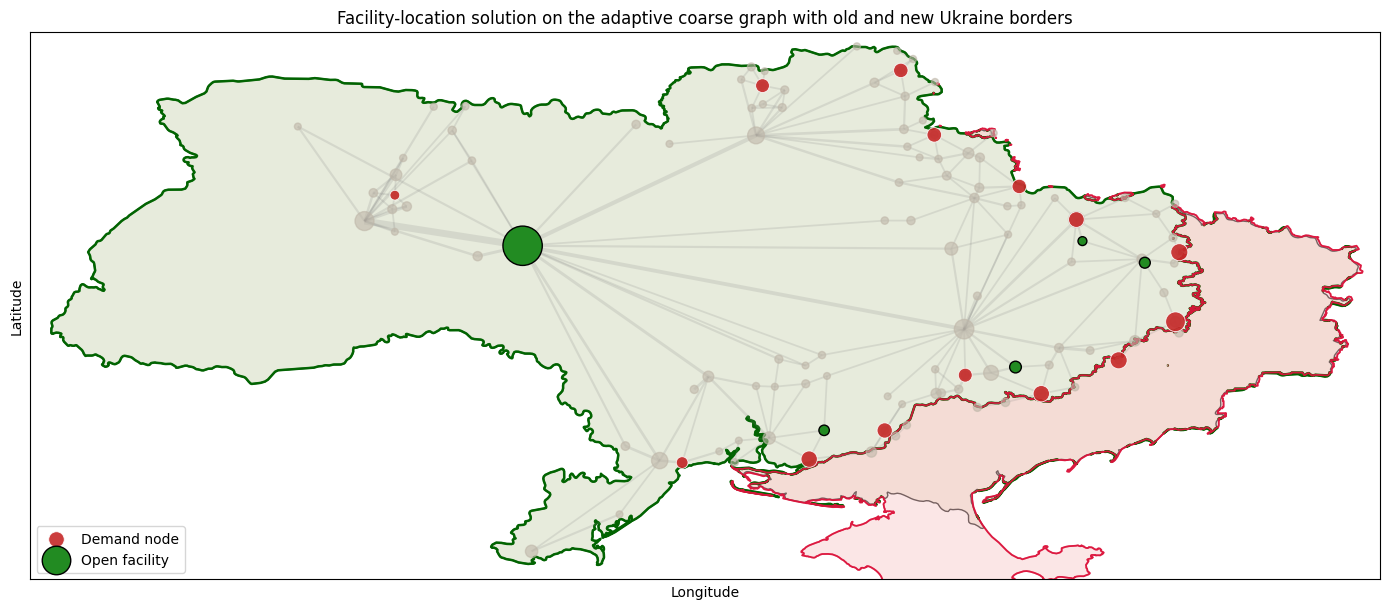

In [7]:
# Visualize the facility-location solution on the adaptive graph style,
# and add the old Ukraine land area, the occupied area, and the new sovereign-held border.

from synthetic_data.config import load_config
from synthetic_data.occupied import load_current_occupied_snapshot, load_ukraine_sovereign_geometry

config = load_config()
occupied = load_current_occupied_snapshot(config)
borders = load_ukraine_sovereign_geometry(config, occupied["occupied_geom"])

adaptive_pos = {n: (CG.nodes[n]["lon"], CG.nodes[n]["lat"]) for n in CG.nodes()}
fig, ax = plt.subplots(figsize=(14, 9))

borders["ukraine_shape"].plot(
    ax=ax,
    color="#f2ecdf",
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    zorder=0,
    label="Ukraine land area (old border)",
)
occupied["occupied_gs"].plot(
    ax=ax,
    color="#f7c8c8",
    alpha=0.45,
    edgecolor="crimson",
    linewidth=1.2,
    zorder=0.4,
    label="Occupied area",
)
borders["sovereign_shape"].plot(
    ax=ax,
    color="#dfead9",
    alpha=0.55,
    edgecolor="darkgreen",
    linewidth=1.5,
    zorder=0.8,
    label="Ukraine sovereign-held area (new border)",
)
borders["sovereign_border_gs"].plot(
    ax=ax,
    color="darkgreen",
    linewidth=1.8,
    alpha=0.95,
    zorder=1.0,
)
occupied["occupied_gs"].boundary.plot(
    ax=ax,
    color="crimson",
    linewidth=1.3,
    alpha=0.95,
    zorder=1.1,
)

edge_list = list(CG.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list] or [1]
edge_widths = [
    0.6 + 4.4 * np.sqrt(d.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, d in edge_list
]
edge_collection = nx.draw_networkx_edges(
    CG,
    adaptive_pos,
    ax=ax,
    edgelist=[(u, v) for u, v, _ in edge_list],
    edge_color="gray",
    alpha=0.18,
    width=edge_widths,
)
edge_collection.set_zorder(2)

base_node_sizes = {n: 20 + 4 * np.sqrt(CG.nodes[n].get("member_count", 1)) for n in CG.nodes()}
base_node_collection = nx.draw_networkx_nodes(
    CG,
    adaptive_pos,
    ax=ax,
    node_size=[base_node_sizes[n] for n in CG.nodes()],
    node_color="#bfb7a9",
    alpha=0.60,
)
base_node_collection.set_zorder(3)

max_demand_amount = max(demand_df["demand_amount"]) if len(demand_df) else 1.0
demand_sizes = [
    25 + 175 * np.sqrt(max(v, 0.0) / max(max_demand_amount, 1e-9))
    for v in demand_df["demand_amount"]
]
ax.scatter(
    demand_df["plot_lon"],
    demand_df["plot_lat"],
    c="#c62828",
    s=demand_sizes,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=5,
    label="Demand node",
)

if open_hubs:
    max_capacity = max(hub_capacity.values()) if hub_capacity else 1.0
    hub_x = [CG.nodes[j]["lon"] for j in open_hubs]
    hub_y = [CG.nodes[j]["lat"] for j in open_hubs]
    hub_s = []
    for j in open_hubs:
        base_size = base_node_sizes[j]
        scale = np.sqrt(max(hub_capacity[j], 0.0) / max(max_capacity, 1e-9))
        hub_s.append(base_size * (1.5 + 0.5 * scale))
    ax.scatter(
        hub_x,
        hub_y,
        s=hub_s,
        c="forestgreen",
        edgecolors="black",
        linewidths=1.0,
        zorder=6,
        label="Open facility",
    )

xmin, ymin, xmax, ymax = borders["ukraine_shape"].total_bounds
ax.set_xlim(xmin - 0.3, xmax + 0.3)
ax.set_ylim(ymin - 0.2, ymax + 0.2)
ax.set_title("Facility-location solution on the adaptive coarse graph with old and new Ukraine borders")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()



## Scenario-aware formulation with the 10 generated attack scenarios

This section extends the baseline model to all 10 generated attack scenarios in `data/attack_scenarios/batch_2026-03-30_set1`.

Implementation notes used here:
- The scenario set `S` is the 10 generated attacks.
- We keep the same candidate facility nodes `N` from the adaptive coarse graph.
- We use the synthetic dataset's `daily_demand` directly as `d_i`, so the scenario model is solving on average daily demand rather than cumulative two-year event totals.
- If a demand coarse node is removed in a scenario, its demand is proxied to the geographically nearest surviving coarse node in that scenario graph. This preserves the geographic demand while still using the post-attack network.
- Scenario thresholds are mapped from the attack budget used to generate the scenario: `K=2 -> T_s=2.5`, `K=3 -> 3`, `K=4 -> 4`, `K=5 -> 5`.
- We use `delta = 0.2`, so at most 2 of the 10 scenarios may violate the service cap through binary slack variables `w_s`.


In [8]:
import json
from pathlib import Path

scenario_root = PROJECT_ROOT / "data/attack_scenarios/batch_2026-03-30_set1"
scenario_dirs = sorted([p for p in scenario_root.iterdir() if p.is_dir() and p.name.startswith("K")])
threshold_by_k = {2.0: 2.25, 3.0: 2.4, 4.0: 2.5, 5.0: 3.0}

# Use the synthetic dataset's daily-average demand directly.
robust_demand_df = demand_df.copy()

D_robust = robust_demand_df["coarse_node"].tolist()
d_robust = dict(zip(robust_demand_df["coarse_node"], robust_demand_df["demand_amount"]))
node_pos = {n: (float(CG.nodes[n]["lon"]), float(CG.nodes[n]["lat"])) for n in N}

scenario_data = []
for scenario_dir in scenario_dirs:
    summary_s = json.loads((scenario_dir / "scenario_summary.json").read_text())
    scenario_bundle = pd.read_pickle(scenario_dir / "scenario_bundle.pkl")
    Gs = scenario_bundle["graphs"]["scenario_graph"]
    surviving_nodes = sorted(Gs.nodes())
    surviving_pos = {n: node_pos[n] for n in surviving_nodes}

    proxy_demand_node = {}
    c_s = {}
    for i in D_robust:
        if i in Gs.nodes:
            proxy = i
        else:
            lon_i, lat_i = node_pos[i]
            proxy = min(
                surviving_nodes,
                key=lambda n: (surviving_pos[n][0] - lon_i) ** 2 + (surviving_pos[n][1] - lat_i) ** 2,
            )
        proxy_demand_node[i] = proxy
        lengths = nx.single_source_dijkstra_path_length(Gs, proxy, weight="travel_time")
        for j in surviving_nodes:
            if j in lengths and np.isfinite(lengths[j]):
                c_s[(i, j)] = float(lengths[j] / 3600.0)

    scenario_data.append(
        {
            "id": scenario_dir.name,
            "K": float(summary_s["base_budget"]),
            "T": float(threshold_by_k[float(summary_s["base_budget"])]),
            "graph": Gs,
            "surviving_nodes": surviving_nodes,
            "proxy_demand_node": proxy_demand_node,
            "c": c_s,
            "summary": summary_s,
        }
    )

scenario_summary_df = pd.DataFrame(
    [
        {
            "scenario": s["id"],
            "K": s["K"],
            "T_s": s["T"],
            "surviving_nodes": len(s["surviving_nodes"]),
            "removed_nodes": len(s["summary"].get("removed_nodes", [])),
            "removed_edges": s["summary"]["edge_impacts"]["removed_edges"],
            "degraded_edges": s["summary"]["edge_impacts"]["degraded_edges"],
        }
        for s in scenario_data
    ]
).sort_values(["K", "scenario"]).reset_index(drop=True)

print(f"Loaded {len(scenario_data)} scenarios from {scenario_root}")
print(f"Total daily demand used in optimization = {sum(d_robust.values()):.3f}")
display(scenario_summary_df)


Loaded 10 scenarios from data/attack_scenarios/batch_2026-03-30_set1
Total daily demand used in optimization = 162.052


,scenario,K,T_s,surviving_nodes,removed_nodes,removed_edges,degraded_edges
0,K2_attack_1,2.0,2.25,112,0,0,0
1,K2_attack_2,2.0,2.25,108,4,18,0
2,K3_attack_1,3.0,2.40,111,1,3,0
3,K3_attack_2,3.0,2.40,109,3,5,0
4,K3_attack_3,3.0,2.40,108,4,6,0
5,K4_attack_1,4.0,2.50,112,0,6,2
6,K4_attack_2,4.0,2.50,112,0,0,3
7,K4_attack_3,4.0,2.50,112,0,4,0
8,K5_attack_1,5.0,3.00,110,2,5,0
9,K5_attack_2,5.0,3.00,109,3,5,0


In [9]:
# Robust / scenario-aware MIP
# min sum_j (a_j y_j + b_j u_j)
# s.t.
#   u_j <= M_cap y_j
#   sum_i x^s_{i,j} <= u_j
#   sum_j x^s_{i,j} = d_i
#   (1 / |N|) * sum_(i,j) c^s_{i,j} x^s_{i,j} <= T_s + M_service w_s
#   sum_s w_s <= |S| * delta

delta = 0.2
M_cap = float(len(N))
M_service = 100.0

scenario_model = gp.Model("scenario_facility_location")

y_scen = scenario_model.addVars(N, vtype=GRB.BINARY, name="y")
u_scen = scenario_model.addVars(N, lb=0.0, vtype=GRB.CONTINUOUS, name="u")
w_scen = scenario_model.addVars([s["id"] for s in scenario_data], vtype=GRB.BINARY, name="w")

x_scen = {}
for s in scenario_data:
    sid = s["id"]
    for i in D_robust:
        for j in s["surviving_nodes"]:
            if (i, j) in s["c"]:
                x_scen[(sid, i, j)] = scenario_model.addVar(
                    lb=0.0,
                    vtype=GRB.CONTINUOUS,
                    name=f"x_{sid}_{i}_{j}",
                )
scenario_model.update()

scenario_model.setObjective(
    gp.quicksum(a[j] * y_scen[j] + b[j] * u_scen[j] for j in N),
    GRB.MINIMIZE,
)

scenario_model.addConstrs((u_scen[j] <= M_cap * y_scen[j] for j in N), name="cap_open")

for s in scenario_data:
    sid = s["id"]
    Ns = s["surviving_nodes"]
    scenario_model.addConstrs(
        (gp.quicksum(x_scen[(sid, i, j)] for i in D_robust if (sid, i, j) in x_scen) <= u_scen[j] for j in Ns),
        name=f"cap_flow_{sid}",
    )
    scenario_model.addConstrs(
        (gp.quicksum(x_scen[(sid, i, j)] for j in Ns if (sid, i, j) in x_scen) == d_robust[i] for i in D_robust),
        name=f"demand_{sid}",
    )
    scenario_model.addConstr(
        (1.0 / len(N))
        * gp.quicksum(
            s["c"][(i, j)] * x_scen[(sid, i, j)]
            for i in D_robust
            for j in Ns
            if (sid, i, j) in x_scen
        )
        <= s["T"] + M_service * w_scen[sid],
        name=f"service_{sid}",
    )

scenario_model.addConstr(
    gp.quicksum(w_scen[s["id"]] for s in scenario_data) <= len(scenario_data) * delta,
    name="scenario_budget",
)

scenario_model.Params.OutputFlag = 1
scenario_model.optimize()

print("Scenario model status:", scenario_model.Status)
print(f"Objective value: {scenario_model.ObjVal:.3f}" if scenario_model.SolCount > 0 else "No feasible solution found")
print(f"delta = {delta:.2f}, allowed violations = {len(scenario_data) * delta:.1f}")


Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Academic license 2788119 - for non-commercial use only - registered to so___@usc.edu
Optimize a model with 1366 rows, 15676 columns and 47533 nonzeros (Min)
Model fingerprint: 0xc5b74639
Model has 224 linear objective coefficients
Variable types: 15554 continuous, 122 integer (122 binary)
Coefficient statistics:
  Matrix range     [1e-03, 1e+02]
  Objective range  [2e-01, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e-01, 4e+01]

Found heuristic solution: objective 53176.736935
Presolve time: 0.02s
Presolved: 1366 rows, 15676 columns, 47533 nonzeros
Variable types: 15554 continuous, 122 integer (122 binary)
Found heuristic solution: objective 51473.920935

Root relaxation: objective 3.469079e+03, 4869 iterations, 0.07 seconds (0.17 work units)

 

In [10]:
if scenario_model.SolCount == 0:
    raise RuntimeError("Scenario-aware Gurobi model did not return a feasible solution.")

open_hubs_scen = [j for j in N if y_scen[j].X > 0.5]
hub_capacity_scen = {j: u_scen[j].X for j in open_hubs_scen}
used_capacity_scen = {
    j: sum(x_scen[(s["id"], i, j)].X for s in scenario_data for i in D_robust if (s["id"], i, j) in x_scen)
    for j in open_hubs_scen
}

scenario_service_rows = []
for s in scenario_data:
    sid = s["id"]
    lhs = (1.0 / len(N)) * sum(
        s["c"][(i, j)] * x_scen[(sid, i, j)].X
        for i in D_robust
        for j in s["surviving_nodes"]
        if (sid, i, j) in x_scen
    )
    scenario_service_rows.append(
        {
            "scenario": sid,
            "K": s["K"],
            "T_s": s["T"],
            "lhs_service": lhs,
            "violated": int(round(w_scen[sid].X)),
        }
    )

scenario_service_df = pd.DataFrame(scenario_service_rows).sort_values(["K", "scenario"]).reset_index(drop=True)
scenario_violations = scenario_service_df.loc[scenario_service_df["violated"] == 1, "scenario"].tolist()

print("Scenario-aware solution summary")
print("-" * 70)
print(f"Opened hubs: {len(open_hubs_scen)} / {len(N)}")
print(f"Total fixed cost: {sum(a[j] * y_scen[j].X for j in N):.3f}")
print(f"Total capacity cost: {sum(b[j] * u_scen[j].X for j in N):.3f}")
print(f"Total objective: {scenario_model.ObjVal:.3f}")
print(f"Violated scenarios ({len(scenario_violations)}): {scenario_violations}")

print("\nOpened hubs")
for j in sorted(open_hubs_scen, key=lambda node: hub_capacity_scen[node], reverse=True):
    attrs = CG.nodes[j]
    print(
        f"  Hub {j}: capacity={hub_capacity_scen[j]:.3f}, aggregated_used={used_capacity_scen[j]:.3f}, "
        f"a_i={attrs['a_i']:.2f}, b_i={attrs['b_i']:.2f}, zone={attrs['zone']}, members={attrs['member_count']}"
    )

display(scenario_service_df)


Scenario-aware solution summary
----------------------------------------------------------------------
Opened hubs: 9 / 112
Total fixed cost: 316.586
Total capacity cost: 6384.495
Total objective: 6701.081
Violated scenarios (2): ['K2_attack_2', 'K4_attack_1']

Opened hubs
  Hub 36: capacity=71.132, aggregated_used=711.315, a_i=40.86, b_i=40.86, zone=near, members=7
  Hub 5: capacity=24.997, aggregated_used=242.279, a_i=40.26, b_i=40.26, zone=near, members=9
  Hub 94: capacity=20.995, aggregated_used=209.945, a_i=39.92, b_i=39.92, zone=mid, members=25
  Hub 39: capacity=11.864, aggregated_used=118.644, a_i=39.75, b_i=39.75, zone=near, members=1
  Hub 114: capacity=10.940, aggregated_used=61.340, a_i=0.16, b_i=0.16, zone=far, members=10456
  Hub 17: capacity=8.305, aggregated_used=83.055, a_i=39.96, b_i=39.96, zone=near, members=3
  Hub 15: capacity=7.762, aggregated_used=77.616, a_i=39.38, b_i=39.38, zone=near, members=32
  Hub 87: capacity=7.693, aggregated_used=67.602, a_i=37.11, b_i

,scenario,K,T_s,lhs_service,violated
0,K2_attack_1,2.0,2.25,2.250000,0
1,K2_attack_2,2.0,2.25,8.413785,1
2,K3_attack_1,3.0,2.40,2.250000,0
3,K3_attack_2,3.0,2.40,2.400000,0
4,K3_attack_3,3.0,2.40,2.202631,0
5,K4_attack_1,4.0,2.50,7.713403,1
6,K4_attack_2,4.0,2.50,2.250000,0
7,K4_attack_3,4.0,2.50,2.250000,0
8,K5_attack_1,5.0,3.00,2.433678,0
9,K5_attack_2,5.0,3.00,2.710328,0


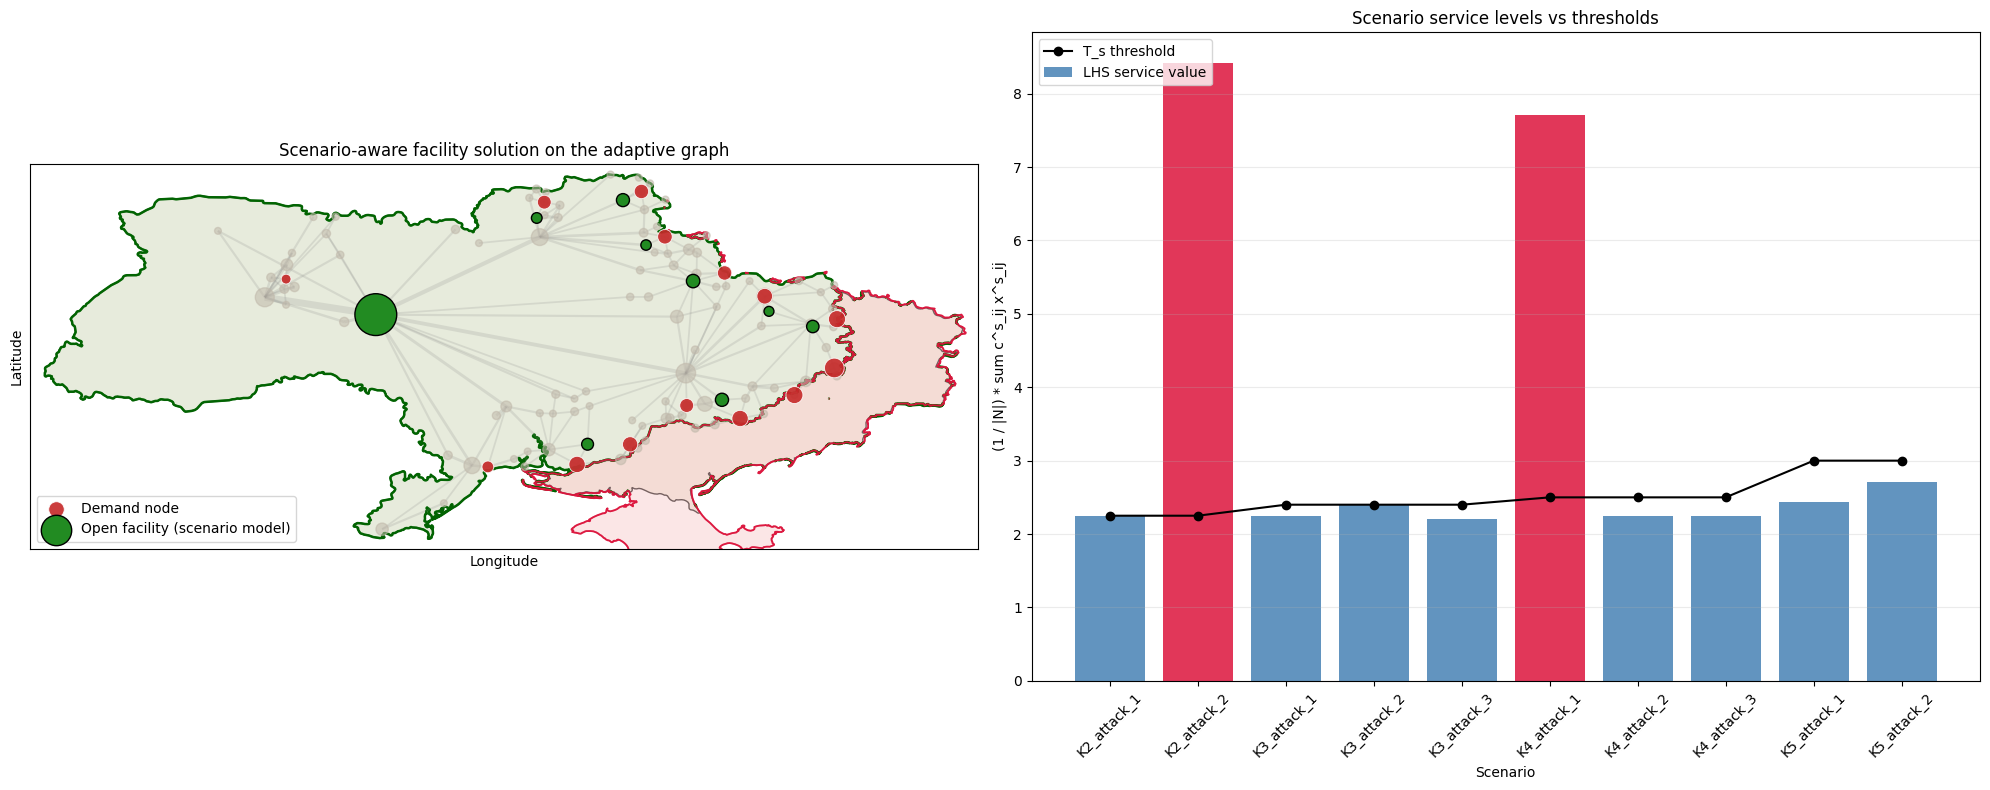

In [11]:
# Visualize the scenario-aware facility solution and the scenario service levels.

from synthetic_data.config import load_config
from synthetic_data.occupied import load_current_occupied_snapshot, load_ukraine_sovereign_geometry

config = load_config()
occupied = load_current_occupied_snapshot(config)
borders = load_ukraine_sovereign_geometry(config, occupied["occupied_geom"])

adaptive_pos = {n: (CG.nodes[n]["lon"], CG.nodes[n]["lat"]) for n in CG.nodes()}
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ax_map, ax_bar = axes

borders["ukraine_shape"].plot(
    ax=ax_map,
    color="#f2ecdf",
    alpha=0.95,
    edgecolor="black",
    linewidth=1.0,
    zorder=0,
)
occupied["occupied_gs"].plot(
    ax=ax_map,
    color="#f7c8c8",
    alpha=0.45,
    edgecolor="crimson",
    linewidth=1.2,
    zorder=0.4,
)
borders["sovereign_shape"].plot(
    ax=ax_map,
    color="#dfead9",
    alpha=0.55,
    edgecolor="darkgreen",
    linewidth=1.5,
    zorder=0.8,
)
borders["sovereign_border_gs"].plot(ax=ax_map, color="darkgreen", linewidth=1.8, alpha=0.95, zorder=1.0)
occupied["occupied_gs"].boundary.plot(ax=ax_map, color="crimson", linewidth=1.3, alpha=0.95, zorder=1.1)

edge_list = list(CG.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list] or [1]
edge_widths = [
    0.6 + 4.4 * np.sqrt(d.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, d in edge_list
]
edge_collection = nx.draw_networkx_edges(
    CG,
    adaptive_pos,
    ax=ax_map,
    edgelist=[(u, v) for u, v, _ in edge_list],
    edge_color="gray",
    alpha=0.18,
    width=edge_widths,
)
edge_collection.set_zorder(2)

base_node_sizes = {n: 20 + 4 * np.sqrt(CG.nodes[n].get("member_count", 1)) for n in CG.nodes()}
base_nodes = nx.draw_networkx_nodes(
    CG,
    adaptive_pos,
    ax=ax_map,
    node_size=[base_node_sizes[n] for n in CG.nodes()],
    node_color="#c0b8aa",
    alpha=0.55,
)
base_nodes.set_zorder(3)

demand_sizes = [25 + 175 * np.sqrt(max(v, 0.0) / max(robust_demand_df["demand_amount"].max(), 1e-9)) for v in robust_demand_df["demand_amount"]]
ax_map.scatter(
    robust_demand_df["plot_lon"],
    robust_demand_df["plot_lat"],
    c="#c62828",
    s=demand_sizes,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.6,
    zorder=5,
    label="Demand node",
)

if open_hubs_scen:
    max_capacity = max(hub_capacity_scen.values()) if hub_capacity_scen else 1.0
    hub_x = [CG.nodes[j]["lon"] for j in open_hubs_scen]
    hub_y = [CG.nodes[j]["lat"] for j in open_hubs_scen]
    hub_s = []
    for j in open_hubs_scen:
        scale = np.sqrt(max(hub_capacity_scen[j], 0.0) / max(max_capacity, 1e-9))
        hub_s.append(base_node_sizes[j] * (1.8 + 0.8 * scale))
    ax_map.scatter(
        hub_x,
        hub_y,
        s=hub_s,
        c="forestgreen",
        edgecolors="black",
        linewidths=1.0,
        zorder=6,
        label="Open facility (scenario model)",
    )

xmin, ymin, xmax, ymax = borders["ukraine_shape"].total_bounds
ax_map.set_xlim(xmin - 0.3, xmax + 0.3)
ax_map.set_ylim(ymin - 0.2, ymax + 0.2)
ax_map.set_title("Scenario-aware facility solution on the adaptive graph")
ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_aspect("equal", adjustable="box")
ax_map.legend(loc="lower left")

bar_colors = ["crimson" if flag else "steelblue" for flag in scenario_service_df["violated"]]
ax_bar.bar(scenario_service_df["scenario"], scenario_service_df["lhs_service"], color=bar_colors, alpha=0.85, label="LHS service value")
ax_bar.plot(scenario_service_df["scenario"], scenario_service_df["T_s"], color="black", marker="o", linewidth=1.5, label="T_s threshold")
ax_bar.set_title("Scenario service levels vs thresholds")
ax_bar.set_ylabel("Cost")
ax_bar.set_xlabel("Scenario")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.legend(loc="upper left")
ax_bar.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
